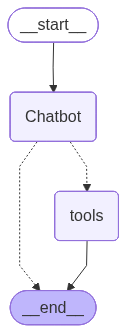

bot: I'm here to help. How can I assist you today?
bot: I'm an AI assistant, but it seems you're looking for information on stocks. If you'd like to know the current stock price of a specific company, I can help you with that. Please let me know the ticker symbol of the company you're interested in.


KeyboardInterrupt: Interrupted by user

In [1]:
from dotenv import load_dotenv
from typing import Annotated
#
# from pydantic_core.core_schema import none_schema
from typing_extensions import TypedDict
from langchain.chat_models import init_chat_model
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition
from langsmith import traceable
from dotenv import load_dotenv
from typing import Annotated

load_dotenv()


class state(TypedDict):
    messages: Annotated[list, add_messages]


@tool
def get_stock_price(symbol: str) -> float:
    """Returns the current stock price for a given ticker symbol.

    Args:
        symbol: The stock ticker symbol (e.g., 'AAPL', 'MSFT', 'AMZN', 'RIL')

    Returns:
        The current stock price as a float. Returns 0.0 if symbol not found.
    """
    return {
        "MSFT": 200.3,

        "AAPL": 100.4,

        "AMZN": 150.0,
        "RIL": 87.6
    }.get(symbol, 0.0)


tools = [get_stock_price]


llm = init_chat_model("groq:llama-3.3-70b-versatile")
llm_with_tools = llm.bind_tools(tools)


@traceable(name="Chatbot Node")
def chatbot(state: state) -> state:
    return {"messages": [llm_with_tools.invoke(state["messages"])]}


builder = StateGraph(state)

builder.add_node("Chatbot", chatbot)
builder.add_node("tools", ToolNode(tools))
builder.add_edge(START, "Chatbot")
builder.add_conditional_edges("Chatbot", tools_condition)
builder.add_edge("Chatbot", END)


graph = builder.compile()
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))
msg = {"role": "user", "content": "hello how are you?"}
response = graph.invoke({"messages": [msg]})

# llm = init_chat_model("groq:llama-3.3-70b-versatile")
# response = llm.invoke("hello")


response["messages"]
state = None
while True:
    msg = input("enter the question: ")
    if msg.lower() in {"quit", "exit"}:
        break
    if state is None:
        state: state = {
            "messages": [{"role": "user", "content": msg}]
        }
    else:
        state["messages"].append({"role": "user", "content": msg})

    state = graph.invoke(state)
    print("bot:", state["messages"][-1].content)

